In [9]:
import json
from collections import deque

import torch
from torchvision import transforms as T

from tqdm import tqdm

import plotly.graph_objects as go
import seaborn as sns

from src.dataloaders.dataloader_for_CNN import mavDataLoader
from src.models.CNN_ResNet50_VO import CNN_ResNet50_VO
from src.models.DeepVO import DeepVO, PairwiseVOModel, DeepVORNN
from src.different_functions.trigan import euler_to_matrix_R, get_motion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Обучение на:', device, sep=' ')

Обучение на: cuda


In [2]:
transform = T.Compose([
    T.Resize((320, 192))
])
dataset_train = mavDataLoader('datasets/euroc_mav', transform=transform, lst_of_datasets=['mav0_easy2'])

In [3]:
model_cnn = CNN_ResNet50_VO()
state_dict_cnn = torch.load('process_of_fitting/fitting_models/CNNResNet50_VO_2_0.tar')
model_cnn.load_state_dict(state_dict_cnn)
model_cnn = model_cnn.to(device)

trajectory = []
trajectory_pred = []

dtrain = iter(dataset_train)
model_cnn.eval()
with torch.no_grad():
    
    x, y, t_m = next(dtrain)
    y_pred = model_cnn(x.unsqueeze(0).to(device)).squeeze().cpu()
    r_pred = euler_to_matrix_R(y_pred[3:])
    motion_pred = get_motion_matrix(r_pred, y_pred[:3])
    
    r = euler_to_matrix_R(y[3:])
    motion = get_motion_matrix(r, y[:3])
    
    trajectory.append(t_m @ motion)
    trajectory_pred.append(t_m @ motion_pred)
    
    dataset_train = tqdm(dtrain, desc=f'Поехали', position=0)
    for item in dataset_train:
        x, y, _ = item
        
        y_pred = model_cnn(x.unsqueeze(0).to(device)).squeeze().cpu()
        r_pred = euler_to_matrix_R(y_pred[3:])
        motion_pred = get_motion_matrix(r_pred, y_pred[:3])
        
        r = euler_to_matrix_R(y[3:])
        motion = get_motion_matrix(r, y[:3])

        T = trajectory[-1]
        T_pred = trajectory_pred[-1]
        
        trajectory.append(T @ motion)
        trajectory_pred.append(T_pred @ motion_pred)
    
        
trajectory_3d = [tr[:3, 3] for tr in trajectory]
trajectory_pred_3d = [tr[:3, 3] for tr in trajectory_pred]

Поехали: 29991it [08:38, 57.84it/s]


<Axes: >

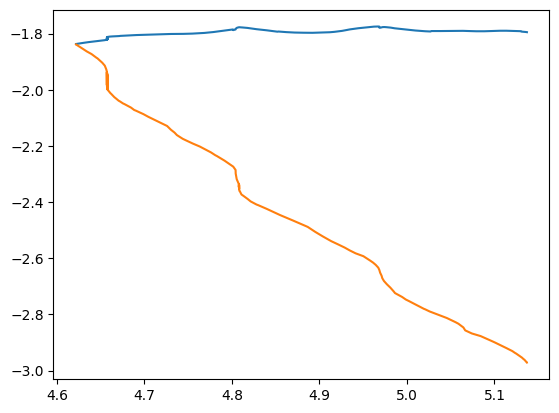

In [25]:
sns.lineplot(x=[x[0].item() for x in trajectory_pred_3d[:1000]], y=[x[1].item() for x in trajectory_3d[:1000]])
sns.lineplot(x=[x[0].item() for x in trajectory_pred_3d[:1000]], y=[x[1].item() for x in trajectory_pred_3d[:1000]])


In [11]:
model_pariwise = PairwiseVOModel()
model_rnn = DeepVORNN()

state_dict_pairwise = torch.load('process_of_fitting/fitting_models/CNN_for_RCNN_1_0.tar')
state_dict_rnn = torch.load('process_of_fitting/fitting_models/DeepVO.tar')


model_pariwise.load_state_dict(state_dict_pairwise)
model_pariwise = model_pariwise.to(device)

model_rnn.load_state_dict(state_dict_rnn)
model_rnn = model_rnn.to(device)

trajectory = []
trajectory_pred = []
count = 0

model_deepVO = DeepVO(model_pariwise.encoder, model_rnn, seq_len=64, device=device)

dtrain = iter(dataset_train)
with torch.no_grad():
    x, y, t_m = next(dtrain)
    model_deepVO.step(x.unsqueeze(0).to(device))

RuntimeError: Expected all tensors to be on the same device, but got tensors is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_cat)

In [ ]:
model_pariwise = PairwiseVOModel()
model_rnn = DeepVORNN()

state_dict_pairwise = torch.load('process_of_fitting/fitting_models/CNN_for_RCNN_1_0.tar')
state_dict_rnn = torch.load('process_of_fitting/fitting_models/DeepVO.tar')


model_pariwise.load_state_dict(state_dict_pairwise)
model_pariwise = model_pariwise.to(device)

model_rnn.load_state_dict(state_dict_rnn)
model_rnn = model_rnn.to(device)

trajectory = []
trajectory_pred = []
count = 0

model_deepVO = DeepVO(model_pariwise.encoder, model_rnn, seq_len=64, device=device)



In [7]:
model_pariwise = PairwiseVOModel()
model_rnn = DeepVORNN()

state_dict_pairwise = torch.load('process_of_fitting/fitting_models/CNN_for_RCNN_1_0.tar')
state_dict_rnn = torch.load('process_of_fitting/fitting_models/DeepVO.tar')


model_pariwise.load_state_dict(state_dict_pairwise)
model_pariwise = model_pariwise.to(device)

model_rnn.load_state_dict(state_dict_rnn)
model_rnn = model_rnn.to(device)

trajectory = []
trajectory_pred = []
count = 0

model_deepVO = DeepVO(model_pariwise.encoder, model_rnn, seq_len=64, device=device)


with torch.no_grad():
    
    dtrain = tqdm(dataset_train, desc=f'Поехали', position=0)
    for item in dtrain:
        
        x, y, t_m = item
        if count > 66:
        
            y_pred = model_deepVO.step(x.unsqueeze(0).to(device)).squeeze().cpu()
            r_pred = euler_to_matrix_R(y_pred[3:])
            motion_pred = get_motion_matrix(r_pred, y_pred[:3])
            
            r = euler_to_matrix_R(y[3:])
            motion = get_motion_matrix(r, y[:3])

            T = trajectory[-1]
            T_pred = trajectory_pred[-1]
            
            trajectory.append(T @ motion)
            trajectory_pred.append(T_pred @ motion_pred)
            
        elif count == 66:
            
            y_pred = model_deepVO.step(x.unsqueeze(0).to(device)).squeeze().cpu()
            r_pred = euler_to_matrix_R(y_pred[3:])
            motion_pred = get_motion_matrix(r_pred, y_pred[:3])
            
            r = euler_to_matrix_R(y[3:])
            motion = get_motion_matrix(r, y[:3])
            
            trajectory.append(t_m @ motion)
            trajectory_pred.append(t_m @ motion_pred)
        
        count += 1
    
        
trajectory_3d = [tr[:3, 3] for tr in trajectory]
trajectory_pred_3d = [tr[:3, 3] for tr in trajectory_pred]

with open('process_of_fitting/trajectory/trajectory_fact_vic2.json', 'w', encoding='utf-8') as w1, open('process_of_fitting/trajectory/trajectory_predict_rcnn_vic2.json', 'w', encoding='utf-8') as w2:
    json.dump(trajectory_3d, w1, indent=4, ensure_ascii=False)
    json.dump(trajectory_pred_3d, w1, indent=4, ensure_ascii=False)

Поехали:   0%|          | 66/29992 [00:00<04:47, 104.09it/s]


AttributeError: 'NoneType' object has no attribute 'squeeze'

In [40]:

a = deque(maxlen=3)

In [50]:
a.append(2)


In [51]:
a

deque([1, 1, 2], maxlen=3)

In [45]:
a[0]

1

In [ ]:


model_pairwise = PairwiseVOModel()
state_dict = torch.load('process_of_fitting/fitting_models/CNN_for_RCNN_1_0.tar')
model_pairwise.load_state_dict(state_dict)